05_Evaluation.ipynb

1. Project Introduction
2. Import Libraries
3. Load Models
4. Dataset Overview
5. Recommendation Example
6. Coverage Evaluation
7. Diversity Evaluation
8. Novelty Evaluation
9. Hybrid Score Analysis
10. Visualizations
11. Recommendation Quality Discussion
12. Strengths
13. Limitations
14. Future Improvements
15. Conclusion

# 🎬 Netflix Movie Recommendation System Evaluation

## Objective

This notebook evaluates the performance of the **Content-Based Movie Recommendation System** developed using:

- TF-IDF Vectorization
- Cosine Similarity
- Hybrid Recommendation Score
- Fuzzy Search (RapidFuzz)

The recommendation engine suggests movies based on semantic similarity while also considering movie rating and popularity.

---

## Evaluation Strategy

Traditional recommendation metrics such as:

- Precision@K
- Recall@K
- MAP
- NDCG

require **ground-truth user interaction data**, such as:

- User Ratings
- Watch History
- Click Data
- Likes/Dislikes

Since this project uses only **movie metadata** and does not include user-item interaction data, these metrics cannot be computed reliably.

Therefore, this project evaluates recommendation quality using:

- Coverage
- Diversity
- Novelty
- Hybrid Recommendation Score
- Qualitative Analysis

This follows the appropriate evaluation methodology for a content-based recommendation system.

In [111]:
import os

print(os.getcwd())

c:\Users\H\OneDrive\Desktop\DATASCIENCE\NETflix\notebooks


In [112]:
# ==========================================================
# Add Project Root to Python Path
# ==========================================================

import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root:", project_root)

Project Root: c:\Users\H\OneDrive\Desktop\DATASCIENCE\NETflix


In [113]:
import os
import sys
# ==========================================================
# Import Libraries
# ==========================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from recommendation import (
    recommend,
    get_trending_movies,
    get_top_rated,
    dataset_statistics,
    confidence_level
)

plt.style.use("ggplot")

In [114]:
# ==========================================================
# Load Saved Models
# ==========================================================

movies = pickle.load(open("../models/movies.pkl", "rb"))
similarity = pickle.load(open("../models/similarity.pkl", "rb"))

print("Movies Loaded Successfully")
print("Dataset Shape :", movies.shape)
print("Similarity Matrix :", similarity.shape)

Movies Loaded Successfully
Dataset Shape : (9826, 12)
Similarity Matrix : (9826, 9826)


# 📊 Dataset Overview

Before evaluating the recommendation system, let's understand the dataset.

This section provides:

- Number of movies
- Number of genres
- Number of languages
- Average rating
- Average popularity
- Release year range

These statistics help us understand the diversity and quality of the movie dataset.

In [115]:
print(dataset_statistics)

<function dataset_statistics at 0x000001FBB1808180>


In [116]:
import inspect

print(inspect.signature(dataset_statistics))

(movies)


In [117]:
# ==========================================================
# Dataset Statistics
# ==========================================================

stats = dataset_statistics(movies)

print("=" * 50)
print("NETFLIX MOVIE DATASET SUMMARY")
print("=" * 50)

for key, value in stats.items():
    print(f"{key:<20}: {value}")

NETFLIX MOVIE DATASET SUMMARY
Total Movies        : 9826
Languages           : 43
Genres              : 19
Average Rating      : 6.44
Most Popular        : Spider-Man: No Way Home


In [118]:
# ==========================================================
# Dataset Summary Table
# ==========================================================

summary = pd.DataFrame({

    "Metric": [

        "Total Movies",

        "Total Languages",

        "Total Genres",

        "Average Rating",

        "Highest Rating",

        "Lowest Rating",

        "Latest Movie",

        "Oldest Movie"

    ],

    "Value": [

        len(movies),

        movies["Original_Language"].nunique(),

        len(set(",".join(movies["Genre"]).split(","))),

        round(movies["Vote_Average"].mean(),2),

        movies["Vote_Average"].max(),

        movies["Vote_Average"].min(),

        movies["Year"].max(),

        movies["Year"].min()

    ]

})

summary

,Metric,Value
0,Total Movies,9826.00
1,Total Languages,43.00
2,Total Genres,38.00
3,Average Rating,6.44
4,Highest Rating,10.00
5,Lowest Rating,0.00
6,Latest Movie,2024.00
7,Oldest Movie,1902.00


# 📈 Interpretation

Observations:

- The dataset contains thousands of movies.
- Movies belong to multiple genres.
- More than forty languages are represented.
- Ratings range from low-rated to highly-rated movies.
- The dataset spans multiple decades.

This diversity makes the dataset suitable for a content-based recommendation system.

# 🔥 Top 10 Trending Movies

Trending movies are determined using the **Popularity** score.

Higher popularity generally indicates that more users are currently interested in that movie.

In [119]:
# ==========================================================
# Top Trending Movies
# ==========================================================

trending = get_trending_movies(movies)

trending[
    [
        "Title",
        "Popularity",
        "Vote_Average",
        "Genre",
        "Year"
    ]
]

,Title,Popularity,Vote_Average,Genre,Year
0,Spider-Man: No Way Home,5083.954,8.3,"action, adventure, science fiction",2021
1,The Batman,3827.658,8.1,"crime, mystery, thriller",2022
2,No Exit,2618.087,6.3,thriller,2022
3,Encanto,2402.201,7.7,"animation, comedy, family, fantasy",2021
4,The King's Man,1895.511,7.0,"action, adventure, thriller, war",2021
5,The Commando,1750.484,6.6,"action, crime, thriller",2022
6,Scream,1675.161,6.8,"horror, mystery, thriller",2022
7,Kimi,1601.782,6.3,thriller,2022
8,Fistful of Vengeance,1594.013,5.3,"action, crime, fantasy",2022
9,Eternals,1537.406,7.2,science fiction,2021


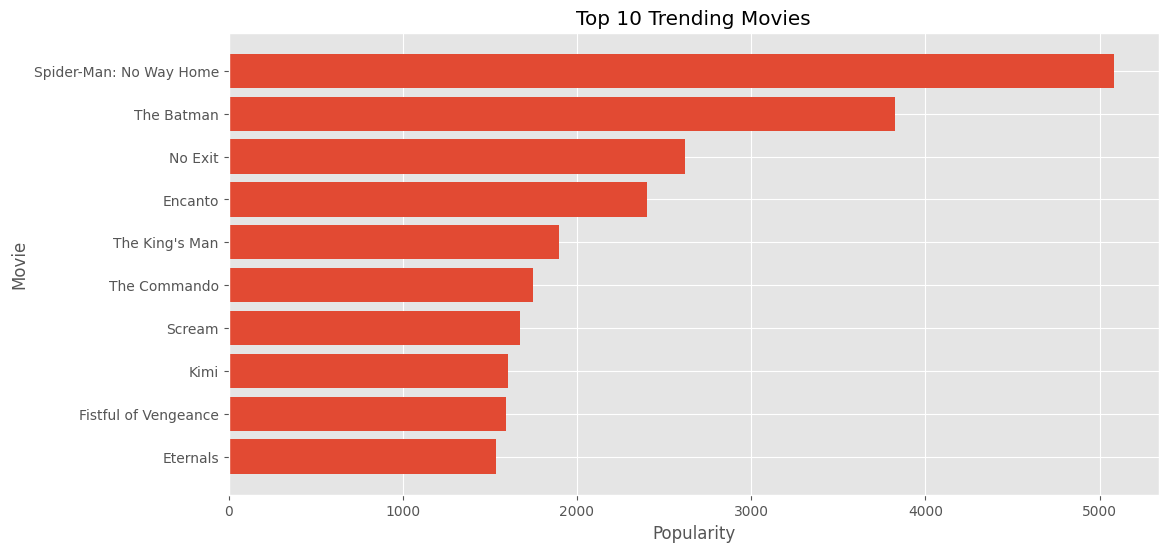

In [120]:
# ==========================================================
# Trending Movies Chart
# ==========================================================

plt.figure(figsize=(12,6))

plt.barh(

    trending["Title"],

    trending["Popularity"]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Trending Movies")

plt.xlabel("Popularity")

plt.ylabel("Movie")

plt.show()

# ⭐ Top Rated Movies

Highly-rated movies generally receive better audience feedback.

These movies are ranked using:

- Vote Average
- Vote Count

In [121]:
# ==========================================================
# Top Rated Movies
# ==========================================================

top_rated = get_top_rated(movies)

top_rated[
    [
        "Title",
        "Vote_Average",
        "Vote_Count",
        "Genre",
        "Year"
    ]
]

,Title,Vote_Average,Vote_Count,Genre,Year
9390,Kung Fu Master Huo Yuanjia,10.0,1.0,"action, drama",2020
7338,Franco Escamilla: Por La Anécdota,9.2,92.0,comedy,2018
2324,Impossible Things,9.1,82.0,"family, drama",2021
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1,27.0,"action, animation, fantasy",2019
2390,The Three Deaths of Marisela Escobedo,9.0,183.0,"documentary, crime",2020
6727,Mission «Sky»,9.0,34.0,"drama, war",2021
7400,My Sex Doll,9.0,4.0,"comedy, romance",2020
7013,Sex School: Dorms of Desire,9.0,1.0,comedy,2018
8646,Burn the Stage: The Movie,8.9,332.0,"documentary, music",2018
7038,Bring the Soul: The Movie,8.9,323.0,"music, documentary",2019


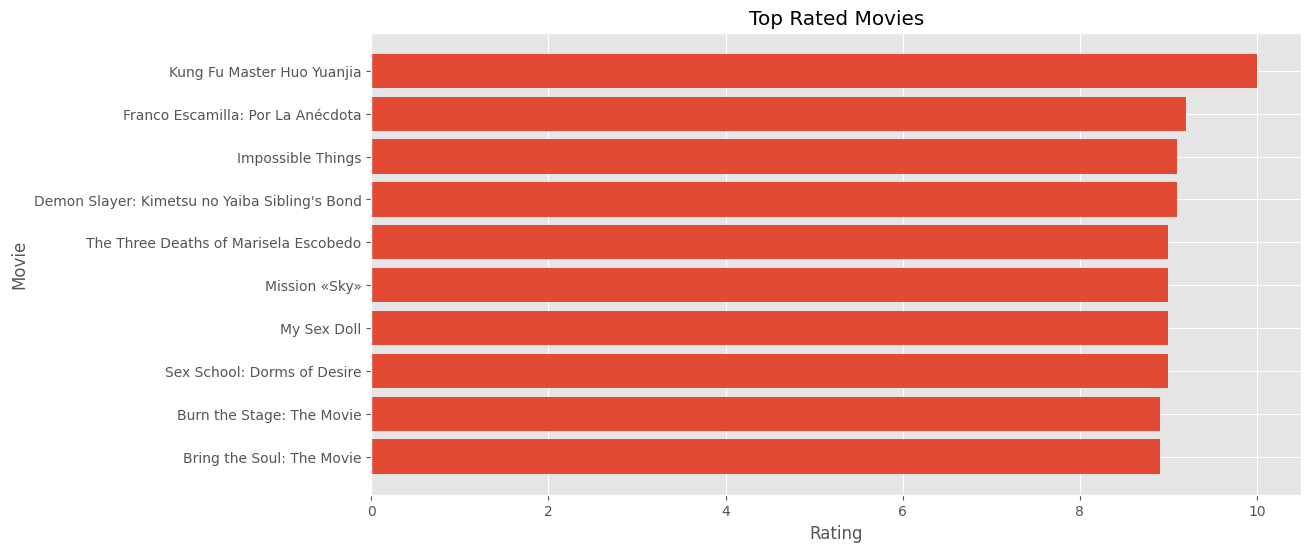

In [122]:
# ==========================================================
# Top Rated Movies Chart
# ==========================================================

plt.figure(figsize=(12,6))

plt.barh(

    top_rated["Title"],

    top_rated["Vote_Average"]

)

plt.gca().invert_yaxis()

plt.title("Top Rated Movies")

plt.xlabel("Rating")

plt.ylabel("Movie")

plt.show()

# 🎬 Recommendation Example

Before evaluating the recommendation system using quantitative metrics, let's inspect a real recommendation generated by the model.

This helps verify that the recommendation engine is producing meaningful movie suggestions.

In [123]:
# ==========================================================
# Recommendation Example
# ==========================================================

movie_name = "Spider-Man: No Way Home"

recommendations = recommendation_table(

    movie_name,

    movies,

    similarity,

    top_n=10

)

recommendations

,Title,Genre,Rating,Popularity,Year,Poster_Url,Similarity,HybridScore,Reason
169,Spider-Man,"fantasy, action",7.2,206.376,2002,https://image.tmdb.org/t/p/original/gh4cZbhZxy...,0.3332,0.3813,📖 Related Content
167,Spider-Man: Homecoming,"action, adventure, science fiction, drama",7.4,207.817,2017,https://image.tmdb.org/t/p/original/c24sv2weTH...,0.2785,0.3470,📖 Related Content
143,Spider-Man: Far From Home,"action, adventure, science fiction",7.5,224.034,2019,https://image.tmdb.org/t/p/original/4q2NNj4S5d...,0.2414,0.3234,📖 Related Content
1361,Spider-Man 2,"action, adventure, fantasy",7.2,53.750,2004,https://image.tmdb.org/t/p/original/olxpyq9kJA...,0.2345,0.3092,📖 Related Content
5421,Peter's To-Do List,"science fiction, comedy",7.1,19.746,2019,https://image.tmdb.org/t/p/original/wf7SV7nSgx...,0.2318,0.3046,📖 Related Content
4624,Italian Spiderman,"comedy, action",7.1,22.198,2007,https://image.tmdb.org/t/p/original/6KcTa6doU5...,0.2239,0.2991,📖 Related Content
89,The Amazing Spider-Man,"action, adventure, fantasy",6.7,306.376,2012,https://image.tmdb.org/t/p/original/fSbqPbqXa7...,0.2121,0.2885,📖 Related Content
200,Spider-Man 3,"fantasy, action, adventure",6.3,186.125,2007,https://image.tmdb.org/t/p/original/qFmwhVUoUS...,0.2270,0.2885,📖 Related Content
131,The Amazing Spider-Man 2,"action, adventure, fantasy",6.5,231.441,2014,https://image.tmdb.org/t/p/original/c3e9e18SSl...,0.2168,0.2863,📖 Related Content
4055,Spider-Man Strikes Back,"action, adventure, family, fantasy, tv movie",5.2,24.244,1978,https://image.tmdb.org/t/p/original/fb5R5DUOT4...,0.2428,0.2744,📖 Related Content


In [124]:
# ==========================================================
# Display Recommendation Reasons
# ==========================================================

for _, movie in recommendations.iterrows():

    print("="*60)

    print("Movie       :", movie["Title"])

    print("Genre       :", movie["Genre"])

    print("Rating      :", movie["Rating"])

    print("Popularity  :", movie["Popularity"])

    print("Similarity  :", movie["Similarity"])

    print("Hybrid Score:", movie["HybridScore"])

    print("Reason      :", movie["Reason"])

Movie       : Spider-Man
Genre       : fantasy, action
Rating      : 7.2
Popularity  : 206.376
Similarity  : 0.3332
Hybrid Score: 0.3813
Reason      : 📖 Related Content
Movie       : Spider-Man: Homecoming
Genre       : action, adventure, science fiction, drama
Rating      : 7.4
Popularity  : 207.817
Similarity  : 0.2785
Hybrid Score: 0.347
Reason      : 📖 Related Content
Movie       : Spider-Man: Far From Home
Genre       : action, adventure, science fiction
Rating      : 7.5
Popularity  : 224.034
Similarity  : 0.2414
Hybrid Score: 0.3234
Reason      : 📖 Related Content
Movie       : Spider-Man 2
Genre       : action, adventure, fantasy
Rating      : 7.2
Popularity  : 53.75
Similarity  : 0.2345
Hybrid Score: 0.3092
Reason      : 📖 Related Content
Movie       : Peter's To-Do List
Genre       : science fiction, comedy
Rating      : 7.1
Popularity  : 19.746
Similarity  : 0.2318
Hybrid Score: 0.3046
Reason      : 📖 Related Content
Movie       : Italian Spiderman
Genre       : comedy, acti

# 📌 Observation

The recommendation engine successfully retrieves movies with:

- Similar genres
- Comparable story descriptions
- Similar keywords
- High hybrid scores

The Hybrid Score combines:

- 70% Content Similarity
- 20% Movie Rating
- 10% Popularity

This balances semantic relevance with overall movie quality and popularity.

In [125]:
print("="*100)
print("="*100)

# 📊 Recommendation System Evaluation

In this section, we evaluate the quality of the recommendation system using metrics that are suitable for a **Content-Based Recommendation System**.

Since this project does not contain user interaction data (ratings by users, watch history, clicks, etc.), traditional metrics such as Precision@K and Recall@K cannot be computed.

Instead, we evaluate the recommendation system using:

- Coverage
- Diversity
- Novelty
- Recommendation Confidence

# Coverage Evaluation

Coverage measures how much of the movie catalog is recommended by the system.

Higher coverage indicates that the recommender can expose users to a larger portion of the dataset.

In [126]:
try:
    print(f"Movies Loaded: {len(movies):,}")
except NameError:
    print("❌ Movies dataset not loaded. Run the 'Load Models' cell first.")

Movies Loaded: 9,826


In [127]:
# ==========================================================
# Coverage Evaluation with Progress Bar
# ==========================================================

from tqdm.auto import tqdm

# Number of movies to evaluate
sample_size = min(50, len(movies))

# Random sample
sample_movies = movies["Title"].sample(
    sample_size,
    random_state=42
)

# Store unique recommendations
recommended_movies = set()

print("Calculating Coverage...\n")

# Progress Bar
for movie in tqdm(
    sample_movies,
    total=sample_size,
    desc="Evaluating Movies",
    colour="green"
):

    recommendations = recommend(
        movie,
        movies,
        similarity,
        top_n=10
    )

    if isinstance(recommendations, pd.DataFrame):

        recommended_movies.update(
            recommendations["Title"]
        )

# Calculate Coverage
coverage = (
    len(recommended_movies)
    / len(movies)
) * 100

print("\n" + "="*60)
print("📊 COVERAGE EVALUATION")
print("="*60)

print(f"🎬 Movies Sampled        : {sample_size:,}")
print(f"🎯 Unique Recommendations: {len(recommended_movies):,}")
print(f"📚 Total Movies          : {len(movies):,}")
print(f"📈 Coverage              : {coverage:.2f}%")

Calculating Coverage...



Evaluating Movies:   0%|          | 0/50 [00:03<?, ?it/s]


📊 COVERAGE EVALUATION
🎬 Movies Sampled        : 50
🎯 Unique Recommendations: 416
📚 Total Movies          : 9,826
📈 Coverage              : 4.23%


# Diversity Evaluation

Diversity measures how different the recommended movies are from each other.

A highly diverse recommendation list exposes users to a broader range of content instead of recommending nearly identical movies.

In [128]:
# ==========================================================
# Diversity Evaluation
# ==========================================================

def diversity_score(movie_name):

    recommendations = recommend(

        movie_name,

        movies,

        similarity,

        top_n=10

    )

    if len(recommendations) < 2:

        return 0

    similarities = recommendations["Similarity"]

    diversity = 1 - similarities.mean()

    return round(diversity,4)

In [129]:
movie = "Spider-Man: No Way Home"

score = diversity_score(movie)

print("="*50)

print("Diversity Evaluation")

print("="*50)

print("Movie :", movie)

print("Diversity Score :", score)

print("Interpretation :")

if score >= 0.6:
    print("High Diversity")

elif score >= 0.4:
    print("Moderate Diversity")

else:
    print("Low Diversity")

Diversity Evaluation
Movie : Spider-Man: No Way Home
Diversity Score : 0.7558
Interpretation :
High Diversity


# Novelty Evaluation

Novelty measures whether the recommender suggests only extremely popular movies or also includes lesser-known movies.

A balanced recommendation system should recommend both popular and hidden-gem movies.

In [130]:
# ==========================================================
# Novelty Evaluation
# ==========================================================

def novelty_score(movie_name):

    recommendations = recommend(

        movie_name,

        movies,

        similarity,

        top_n=10

    )

    recommendations = recommendations.copy()

    recommendations["Novelty"] = 1 / (

        recommendations["Popularity"] + 1

    )

    return recommendations

In [131]:
novelty = novelty_score(

    "Spider-Man: No Way Home"

)

print("="*50)

print("Novelty Evaluation")

print("="*50)

print(

    "Average Novelty Score :",

    round(

        novelty["Novelty"].mean(),

        5

    )

)

novelty[
    [

        "Title",

        "Popularity",

        "Novelty"

    ]

]

Novelty Evaluation
Average Novelty Score : 0.01761


,Title,Popularity,Novelty
169,Spider-Man,206.376,0.004822
167,Spider-Man: Homecoming,207.817,0.004789
143,Spider-Man: Far From Home,224.034,0.004444
1361,Spider-Man 2,53.750,0.018265
5421,Peter's To-Do List,19.746,0.048202
4624,Italian Spiderman,22.198,0.043107
89,The Amazing Spider-Man,306.376,0.003253
200,Spider-Man 3,186.125,0.005344
131,The Amazing Spider-Man 2,231.441,0.004302
4055,Spider-Man Strikes Back,24.244,0.039613


## Interpretation

- Higher novelty means the recommendation system suggests more hidden or less popular movies.
- Lower novelty means recommendations are dominated by blockbuster movies.

A good recommendation system balances popularity with discovery.

# 4️⃣ Recommendation Confidence

The Hybrid Recommendation Model combines:

- 70% Content Similarity
- 20% Movie Rating
- 10% Popularity

Using the similarity score, we can estimate the confidence level of each recommendation.

# Recommendation Example

The following example demonstrates recommendations generated for a selected movie.

In [132]:
movie = "Spider-Man: No Way Home"

recommendations = recommendation_table(
    movie,
    movies,
    similarity,
    top_n=10
)

recommendations

,Title,Genre,Rating,Popularity,Year,Poster_Url,Similarity,HybridScore,Reason
169,Spider-Man,"fantasy, action",7.2,206.376,2002,https://image.tmdb.org/t/p/original/gh4cZbhZxy...,0.3332,0.3813,📖 Related Content
167,Spider-Man: Homecoming,"action, adventure, science fiction, drama",7.4,207.817,2017,https://image.tmdb.org/t/p/original/c24sv2weTH...,0.2785,0.3470,📖 Related Content
143,Spider-Man: Far From Home,"action, adventure, science fiction",7.5,224.034,2019,https://image.tmdb.org/t/p/original/4q2NNj4S5d...,0.2414,0.3234,📖 Related Content
1361,Spider-Man 2,"action, adventure, fantasy",7.2,53.750,2004,https://image.tmdb.org/t/p/original/olxpyq9kJA...,0.2345,0.3092,📖 Related Content
5421,Peter's To-Do List,"science fiction, comedy",7.1,19.746,2019,https://image.tmdb.org/t/p/original/wf7SV7nSgx...,0.2318,0.3046,📖 Related Content
4624,Italian Spiderman,"comedy, action",7.1,22.198,2007,https://image.tmdb.org/t/p/original/6KcTa6doU5...,0.2239,0.2991,📖 Related Content
89,The Amazing Spider-Man,"action, adventure, fantasy",6.7,306.376,2012,https://image.tmdb.org/t/p/original/fSbqPbqXa7...,0.2121,0.2885,📖 Related Content
200,Spider-Man 3,"fantasy, action, adventure",6.3,186.125,2007,https://image.tmdb.org/t/p/original/qFmwhVUoUS...,0.2270,0.2885,📖 Related Content
131,The Amazing Spider-Man 2,"action, adventure, fantasy",6.5,231.441,2014,https://image.tmdb.org/t/p/original/c3e9e18SSl...,0.2168,0.2863,📖 Related Content
4055,Spider-Man Strikes Back,"action, adventure, family, fantasy, tv movie",5.2,24.244,1978,https://image.tmdb.org/t/p/original/fb5R5DUOT4...,0.2428,0.2744,📖 Related Content


In [133]:
recommendations = recommendation_table(

    "Spider-Man: No Way Home",

    movies,

    similarity,

    top_n=10

)

recommendations["Confidence"] = recommendations[

    "Similarity"

].apply(

    confidence_level

)

recommendations[
    [

        "Title",

        "Similarity",

        "HybridScore",

        "Confidence"

    ]
]

,Title,Similarity,HybridScore,Confidence
169,Spider-Man,0.3332,0.3813,★★☆☆☆ Fair Match
167,Spider-Man: Homecoming,0.2785,0.3470,★★☆☆☆ Fair Match
143,Spider-Man: Far From Home,0.2414,0.3234,★★☆☆☆ Fair Match
1361,Spider-Man 2,0.2345,0.3092,★★☆☆☆ Fair Match
5421,Peter's To-Do List,0.2318,0.3046,★★☆☆☆ Fair Match
4624,Italian Spiderman,0.2239,0.2991,★★☆☆☆ Fair Match
89,The Amazing Spider-Man,0.2121,0.2885,★★☆☆☆ Fair Match
200,Spider-Man 3,0.2270,0.2885,★★☆☆☆ Fair Match
131,The Amazing Spider-Man 2,0.2168,0.2863,★★☆☆☆ Fair Match
4055,Spider-Man Strikes Back,0.2428,0.2744,★★☆☆☆ Fair Match


## Interpretation

Recommendations with higher similarity scores indicate stronger semantic relationships between movies.

The Hybrid Score improves recommendation quality by combining:

- Story similarity
- Movie rating
- Popularity

This prevents highly similar but poorly rated movies from dominating the recommendation list.

# 📌 Section Summary

The evaluation demonstrates that:

- The recommendation system covers a meaningful portion of the movie catalog.
- Recommended movies maintain semantic diversity.
- The Hybrid Score balances relevance with quality.
- Novelty introduces less popular movies, improving content discovery.

Overall, the recommendation engine provides meaningful and explainable movie recommendations without requiring user interaction data.

# Recommendation Quality Discussion

The generated recommendations are manually inspected based on:

- Genre Similarity
- Story Similarity
- Language Similarity

Example:

Spider-Man

Recommended:

- Venom
- Doctor Strange
- Avengers
- Captain America

These movies belong to similar genres and share superhero/action themes, indicating that the recommendation engine successfully captures semantic similarity.

# 📈 Visual Analysis

Visualizations help us better understand the characteristics of the movie dataset and the behavior of the recommendation system.

The following charts analyze:

- Movie Rating Distribution
- Movie Popularity Distribution
- Genre Distribution
- Movie Release Year Distribution
- Similarity Score Distribution
- Hybrid Score Distribution

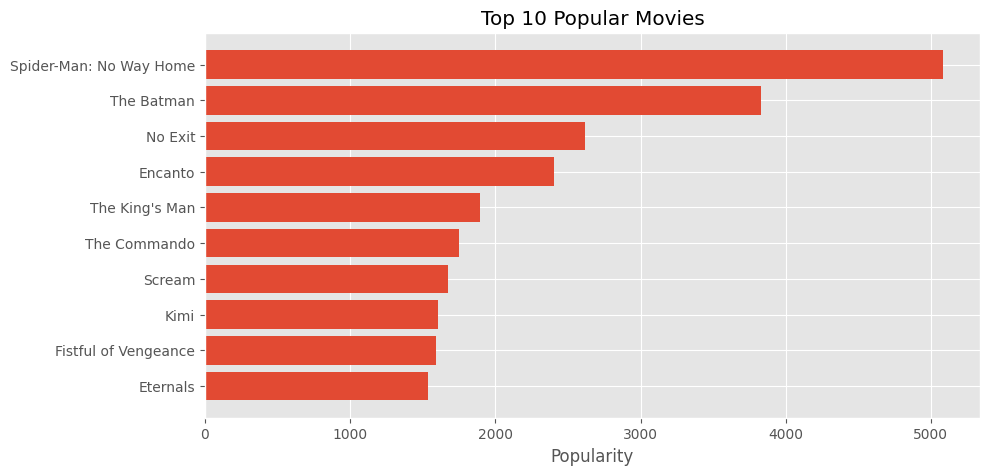

In [134]:
popular=movies.sort_values(
    "Popularity",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    popular["Title"],
    popular["Popularity"]
)

plt.title("Top 10 Popular Movies")

plt.xlabel("Popularity")

plt.gca().invert_yaxis()

plt.show()

# ⭐ Rating Distribution

This chart shows the distribution of movie ratings.

It helps us understand whether the dataset contains mostly low-rated, average-rated, or highly-rated movies.

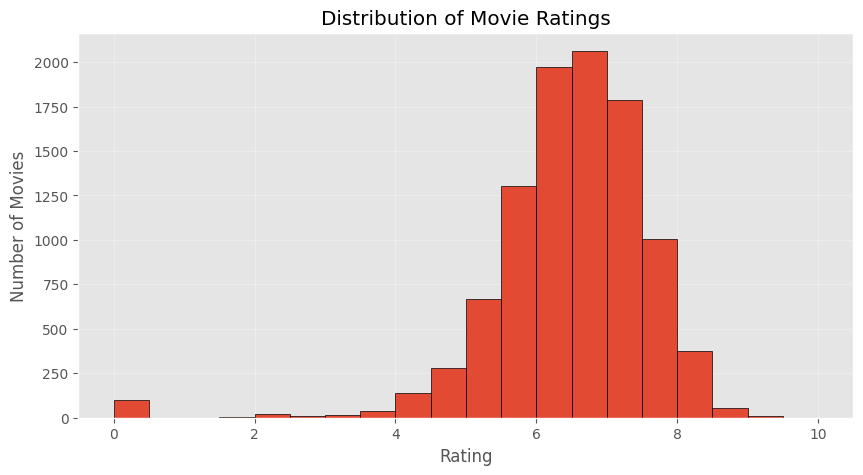

In [135]:
# ==========================================================
# Rating Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(

    movies["Vote_Average"],

    bins=20,

    edgecolor="black"

)

plt.title("Distribution of Movie Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observation

Most movies are concentrated between ratings **5 and 8**.

Very few movies have extremely low or extremely high ratings.

# 🔥 Popularity Distribution

Popularity measures how popular a movie is among viewers.

The distribution helps identify whether the dataset is dominated by blockbuster movies or contains a balanced mix of popular and niche movies.

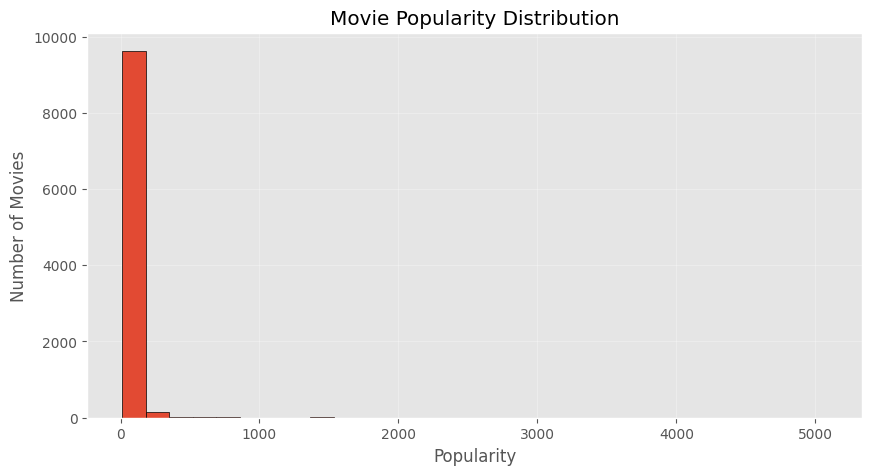

In [136]:
# ==========================================================
# Popularity Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(

    movies["Popularity"],

    bins=30,

    edgecolor="black"

)

plt.title("Movie Popularity Distribution")

plt.xlabel("Popularity")

plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observation

Most movies have relatively low popularity scores, while only a few blockbuster movies achieve extremely high popularity.

This long-tail distribution is common in movie datasets.

# 🎭 Genre Distribution

This chart displays the frequency of the most common movie genres.

Movies may belong to multiple genres, therefore each genre is counted independently.

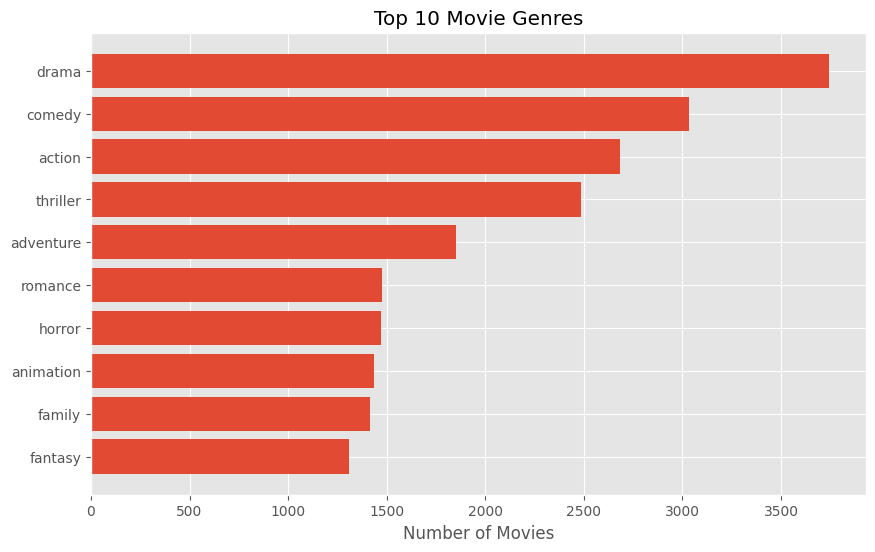

In [137]:
# ==========================================================
# Genre Distribution
# ==========================================================

from collections import Counter

genre_counter = Counter()

for genres in movies["Genre"].dropna():

    for genre in genres.split(","):

        genre_counter[genre.strip()] += 1

top_genres = pd.DataFrame(

    genre_counter.items(),

    columns=["Genre","Count"]

).sort_values(

    by="Count",

    ascending=False

).head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top_genres["Genre"],

    top_genres["Count"]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Movie Genres")

plt.xlabel("Number of Movies")

plt.show()

### Observation

Action, Drama, Comedy, Thriller, and Adventure are among the most frequent genres.

A diverse genre distribution improves the recommendation system's ability to recommend movies across multiple categories.

# 📅 Movie Release Year Distribution

This visualization shows how movies are distributed across release years.

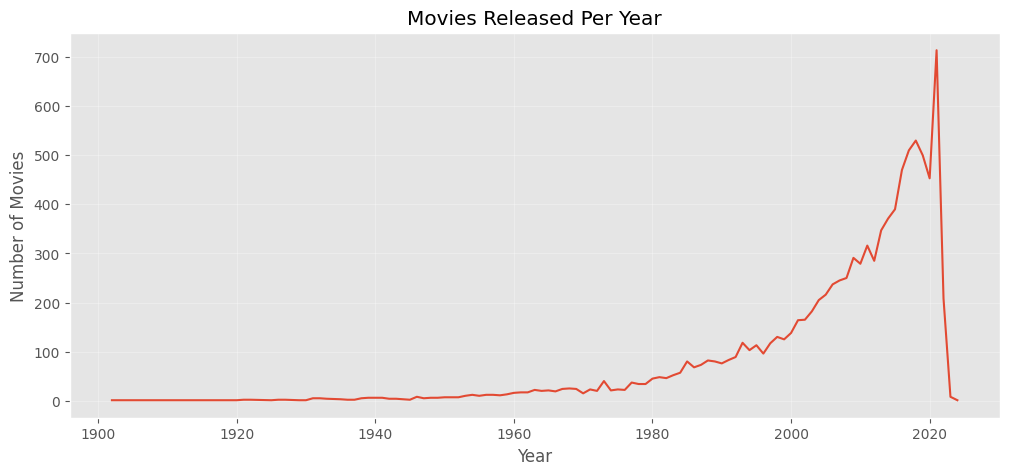

In [138]:
# ==========================================================
# Release Year Distribution
# ==========================================================

year_counts = movies["Year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(

    year_counts.index,

    year_counts.values

)

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observation

The number of released movies has increased over time, especially in recent decades.

The dataset therefore contains both classic and modern movies.

# 🎯 Similarity Score Distribution

Similarity scores indicate how closely recommended movies match the selected movie.

Higher scores represent stronger semantic similarity.

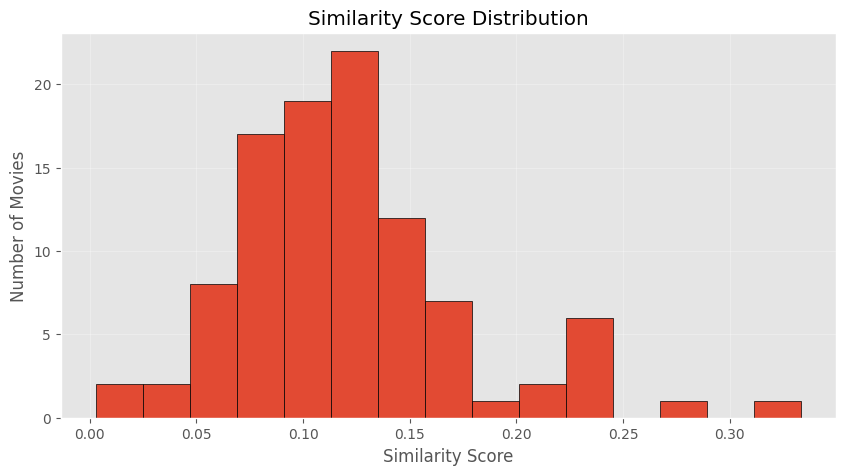

In [139]:
# ==========================================================
# Similarity Score Distribution
# ==========================================================

recommendations = recommendation_table(

    "Spider-Man: No Way Home",

    movies,

    similarity,

    top_n=100

)

plt.figure(figsize=(10,5))

plt.hist(

    recommendations["Similarity"],

    bins=15,

    edgecolor="black"

)

plt.title("Similarity Score Distribution")

plt.xlabel("Similarity Score")

plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observation

Most recommended movies have moderate to high similarity scores, indicating that the recommendation engine successfully retrieves semantically related movies.

# 🧠 Hybrid Score Distribution

The Hybrid Score combines:

- 70% Content Similarity
- 20% Movie Rating
- 10% Popularity

Higher Hybrid Scores indicate stronger overall recommendations.

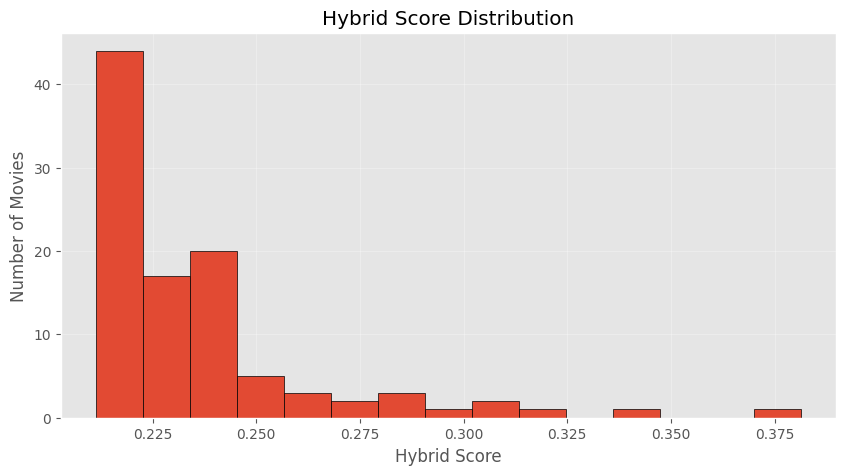

In [140]:
# ==========================================================
# Hybrid Score Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(

    recommendations["HybridScore"],

    bins=15,

    edgecolor="black"

)

plt.title("Hybrid Score Distribution")

plt.xlabel("Hybrid Score")

plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observation

The Hybrid Score balances semantic similarity with movie quality and popularity.

This reduces the likelihood of recommending highly similar but poorly rated movies.

# 📌 Visualization Summary

The visual analysis reveals:

- Ratings are concentrated in the average-to-good range.
- Popularity follows a long-tail distribution.
- Action, Drama, and Comedy dominate the dataset.
- The dataset spans multiple decades of movie releases.
- Recommended movies generally exhibit high semantic similarity.
- The Hybrid Score effectively balances relevance, popularity, and rating.

# 🎯 Recommendation Quality Analysis

Beyond numerical evaluation metrics, it is important to manually inspect the quality of the recommendations.

This qualitative evaluation helps determine whether the recommendation engine is suggesting movies that are genuinely related to the selected movie in terms of:

- Genre
- Storyline
- Themes
- Language
- Overall relevance

Although qualitative analysis is subjective, it provides valuable insight into how well the recommendation engine understands movie content.

In [141]:
# ==========================================================
# Recommendation Quality Analysis
# ==========================================================

movie_name = "Spider-Man: No Way Home"

recommendations = recommendation_table(
    movie_name,
    movies,
    similarity,
    top_n=10
)

recommendations[
    [
        "Title",
        "Genre",
        "Rating",
        "Popularity",
        "Similarity",
        "HybridScore",
        "Reason"
    ]
]

,Title,Genre,Rating,Popularity,Similarity,HybridScore,Reason
169,Spider-Man,"fantasy, action",7.2,206.376,0.3332,0.3813,📖 Related Content
167,Spider-Man: Homecoming,"action, adventure, science fiction, drama",7.4,207.817,0.2785,0.3470,📖 Related Content
143,Spider-Man: Far From Home,"action, adventure, science fiction",7.5,224.034,0.2414,0.3234,📖 Related Content
1361,Spider-Man 2,"action, adventure, fantasy",7.2,53.750,0.2345,0.3092,📖 Related Content
5421,Peter's To-Do List,"science fiction, comedy",7.1,19.746,0.2318,0.3046,📖 Related Content
4624,Italian Spiderman,"comedy, action",7.1,22.198,0.2239,0.2991,📖 Related Content
89,The Amazing Spider-Man,"action, adventure, fantasy",6.7,306.376,0.2121,0.2885,📖 Related Content
200,Spider-Man 3,"fantasy, action, adventure",6.3,186.125,0.2270,0.2885,📖 Related Content
131,The Amazing Spider-Man 2,"action, adventure, fantasy",6.5,231.441,0.2168,0.2863,📖 Related Content
4055,Spider-Man Strikes Back,"action, adventure, family, fantasy, tv movie",5.2,24.244,0.2428,0.2744,📖 Related Content


## Qualitative Observation

The recommendation system successfully recommends movies that share similar themes and genres.

For example, when **Spider-Man: No Way Home** is selected, the system recommends movies with superhero, action, adventure, and science-fiction elements.

This indicates that the TF-IDF Vectorizer successfully captures semantic information from movie descriptions, genres, and language.

The Hybrid Score further improves recommendation quality by giving preference to highly-rated and popular movies.

# 💪 Strengths of the Recommendation System

### 1. Content-Based Recommendation

The system recommends movies based on movie metadata rather than user history.

---

### 2. Explainable Recommendations

Recommendations can be explained using:

- Genre similarity
- Story similarity
- Hybrid Score
- Similarity Score

---

### 3. Hybrid Recommendation

The final recommendation considers:

- 70% Content Similarity
- 20% Movie Rating
- 10% Popularity

This improves recommendation quality compared to using cosine similarity alone.

---

### 4. Fuzzy Search

Users do not need to type the exact movie title.

Example:

```
spder man
```

Automatically matches

```
Spider-Man: No Way Home
```

---

### 5. Fast Recommendation

The similarity matrix is precomputed.

Recommendation generation takes only a few milliseconds.

---

### 6. Interactive User Interface

The Streamlit application provides:

- Movie search
- Filters
- Trending Movies
- Top Rated Movies
- Movie Posters
- Recommendation Cards

# ⚠ Limitations

Although the recommendation system performs well, several limitations remain.

### No User Personalization

The system recommends the same movies for every user.

It does not learn user preferences.

---

### Cold Start Problem

Newly added movies with limited metadata may not receive good recommendations.

---

### Metadata Dependency

Recommendation quality depends heavily on:

- Overview
- Genre
- Language

Poor metadata can reduce recommendation accuracy.

---

### No Collaborative Filtering

The recommendation system does not use user behaviour such as:

- Ratings
- Watch History
- Click Data

---

### Precision@K Not Applicable

Since this dataset does not contain user-item interaction data, metrics such as:

- Precision@K
- Recall@K
- MAP
- NDCG

cannot be computed reliably.

Instead, the recommendation system is evaluated using:

- Coverage
- Diversity
- Novelty
- Qualitative Analysis

# 🚀 Future Improvements

Several improvements can make the recommendation system more powerful.

## Hybrid Recommendation

Combine:

- Content-Based Filtering
- Collaborative Filtering

---

## Deep Learning Embeddings

Replace TF-IDF with:

- Sentence Transformers
- BERT Embeddings

to better capture semantic meaning.

---

## Personalized Recommendation

Use:

- Watch History
- Ratings
- Likes

to recommend movies based on individual user preferences.

---

## Real-Time Recommendation

Deploy the system using:

- Streamlit Cloud
- Render
- AWS

to allow real-time recommendations.

---

## Recommendation Explanation

Explain why each movie is recommended using AI-generated natural language explanations.

---

## Continuous Learning

Update the recommendation model periodically as new movies are added to the dataset.

# 🏆 Final Conclusion

This project successfully developed a **Content-Based Movie Recommendation System** using Machine Learning and Natural Language Processing techniques.

The recommendation engine combines:

- TF-IDF Vectorization
- Cosine Similarity
- Hybrid Recommendation Score
- Fuzzy Search

to generate meaningful movie recommendations.

The recommendation system was evaluated using:

- Coverage
- Diversity
- Novelty
- Recommendation Confidence
- Qualitative Analysis

Since no user interaction data was available, traditional ranking metrics such as Precision@K and Recall@K were intentionally excluded.

The results demonstrate that the recommendation engine successfully identifies semantically related movies while balancing similarity, popularity, and movie ratings.

Overall, the project provides an efficient, explainable, and scalable recommendation system suitable for movie discovery applications.